In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [2]:
iris = load_iris()
X = pd.DataFrame(iris['data'],columns=iris['feature_names']) # input for train
y = pd.Series(iris["target"],name='actual species')  # target 
target_map = {idx:str(val) for idx,val in enumerate(iris.target_names)}

In [3]:
iris_df = X.copy()
iris_df['species'] = y
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [5]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


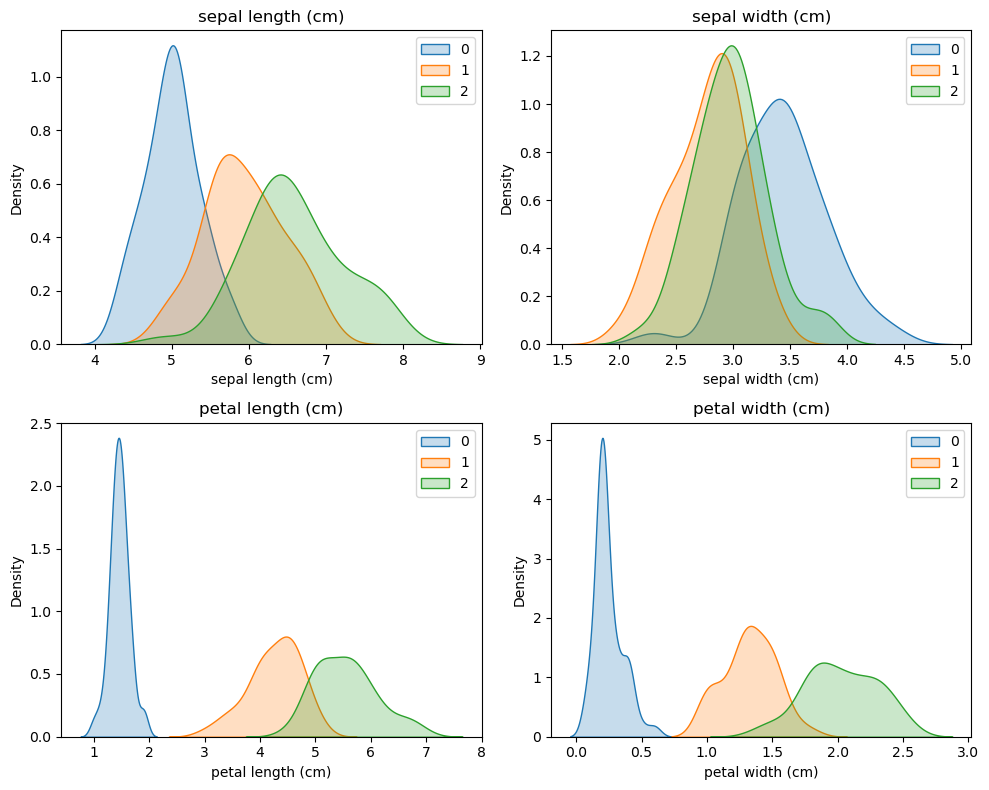

In [6]:
features = iris_df.select_dtypes(include="number").columns.drop("species")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for feature, ax in zip(features, axes.flat):
    for target in iris_df["species"].unique():
        sns.kdeplot(
            data=iris_df[iris_df["species"] == target],
            x=feature, label=target, fill=True, ax=ax
        )
    ax.set_title(feature)
    ax.legend()

plt.tight_layout()
plt.show()

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Support Vector Machine (SVM) : 

In [9]:
svm_models = {
    "linear": SVC(C=1.0,kernel="linear",random_state=20),
    "poly": SVC(C=1.0,kernel="poly", degree=3,random_state=20),
    "rbf": SVC(C=1.0,kernel="rbf",gamma="scale",random_state=20)
}

In [10]:
res = []
for name,model in svm_models.items():
    model.fit(X_train_scaled,y_train)
    y_train_predict = model.predict(X_train_scaled)
    y_test_predict = model.predict(X_test_scaled)
    train_accuracy = accuracy_score(y_train,y_train_predict)
    test_accuracy = accuracy_score(y_test,y_test_predict)
    res.append([name,train_accuracy,test_accuracy])
    print(name)
    print(f"train accuacy : {train_accuracy}")
    print(f"test accuacy : {test_accuracy}")
    print("="*20)
    
res

linear
train accuacy : 0.975
test accuacy : 1.0
poly
train accuacy : 0.9333333333333333
test accuacy : 0.9
rbf
train accuacy : 0.975
test accuacy : 0.9666666666666667


[['linear', 0.975, 1.0],
 ['poly', 0.9333333333333333, 0.9],
 ['rbf', 0.975, 0.9666666666666667]]

In [11]:
scaled = StandardScaler()
X_scaled = scaled.fit_transform(X)

In [12]:
kernels = ["linear","poly","rbf"]
cv_result = {}

for kernel in kernels:
    svm = SVC(kernel=kernel,C=1.0,gamma='scale',random_state=20)
    scores = cross_val_score(estimator=svm,X=X_scaled,y=y,cv=10,scoring='accuracy')
    cv_result[kernel] = scores.mean()
    print(f"{kernel.title()} SVM : Mean CV Accuracy = {scores.mean()}")

Linear SVM : Mean CV Accuracy = 0.9666666666666668
Poly SVM : Mean CV Accuracy = 0.9400000000000001
Rbf SVM : Mean CV Accuracy = 0.9666666666666666


In [13]:
best_kerenl = max(cv_result,key=cv_result.get)
print(f"Best kerenl by cross validation : {best_kerenl.upper()} with accuracy score {cv_result[best_kerenl]:.4f}")

Best kerenl by cross validation : LINEAR with accuracy score 0.9667


## Hyperparameter Tuning :

In [14]:
from sklearn.model_selection import GridSearchCV

In [15]:
param_grid = {
    'C' : [0.1, 0.5, 1, 2, 10, 20, 100],
    'gamma' : ['scale','auto'],
    'kernel' : ['linear','poly','rbf']
}

In [16]:
grid_search = GridSearchCV(SVC(random_state=20),param_grid=param_grid,scoring='accuracy',cv=10,n_jobs=-1)

In [17]:
grid_search.fit(X_scaled,y)

,estimator,SVC(random_state=20)
,param_grid,"{'C': [0.1, 0.5, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'poly', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.5


In [18]:
grid_search.best_params_

{'C': 0.5, 'gamma': 'scale', 'kernel': 'linear'}

In [19]:
grid_search.best_score_

np.float64(0.9800000000000001)